# Training notebook

This notebook contains the full training procedure for the final recommendation model, including preprocessing, hyperparameter optimisation, alternating least squares updates, and feature-aware latent factor training.

The notebook is provided primarily for transparency and reproducibility of the modelling pipeline. Running the complete training process is computationally expensive and may require a substantial amount of time to finish on standard hardware.

For this reason, it is not necessary to execute this notebook as part of the main project workflow. A pre-trained model checkpoint is included separately and is loaded directly in Notebook 3 for analysis, visualisation, and recommendation generation.

### Load dataset

This cell loads the ratings data from a CSV file into a pandas DataFrame and separates the main numerical columns for subsequent processing.

In [1]:
import pandas as pd

# Load ratings data from file
ratings = pd.read_csv("../data/ml-32m/ratings.csv")
data = ratings.iloc[:, : -1]

# Load movies data
movies = pd.read_csv("../data/ml-32m/movies.csv")

### Clean and enrich movie metadata

This cell processes the movie metadata by mapping movie IDs to titles, cleaning genre labels, and extracting additional temporal features.

In particular, movie release years are extracted from titles and used to construct a decade variable (with a special grouping for films released before the 1950s). Missing values are handled explicitly to ensure consistency in later feature encoding and modelling steps.

In [2]:
from utils import extract_year

# Map movie IDs to titles
movieid_to_title = dict(zip(movies['movieId'], movies['title']))

# Convert genre strings to lists and clean out missing/invalid genre labels
movies['genres'] = movies['genres'].str.split('|').apply(
    lambda lst: [g for g in lst if g != '(no genres listed)']
)

# Extract year and compute decade
movies['year'] = movies['title'].map(extract_year)
movies['decade'] = ((movies['year'] // 10) * 10).astype('Int64')
movies['decade'] = movies['decade'].astype('string') + "s"
movies.loc[movies['year'] < 1950, 'decade'] = 'pre 1950s'

# Ensure decade is string and handle missing values
movies['decade'] = movies['decade'].astype('string')
movies['decade'] = movies['decade'].where(movies['decade'].notna(), None)

# Fill missing decade for encoding
movies['decade'] = movies['decade'].fillna('SKIP_THIS')

# Select relevant columns
movies = movies[['movieId', 'title', 'genres', 'decade']]

### Construct item feature matrix

This cell builds a feature representation for each movie by combining genre and decade information.

Genres are encoded using a multi-hot representation, allowing each movie to belong to multiple genre categories simultaneously. Decades are encoded using one-hot encoding over valid time periods, capturing temporal structure in the catalogue.

The resulting feature matrix concatenates both representations into a single item-level feature space, which will later be used for modelling and analysis.

In [3]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder

# Multi-hot encode genres
mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(movies['genres'])

# One-hot encode decades
valid_decades = sorted([d for d in movies['decade'].dropna().unique() if d != 'SKIP_THIS'])
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', categories=[valid_decades])
decade_features = ohe.fit_transform(movies[['decade']])

# Combine genre and decade features
item_features = np.hstack([genre_features, decade_features])

# Feature names
decade_feature_names = [f"decade_{d}" for d in valid_decades]
genre_feature_names = [f"genre_{g}" for g in mlb.classes_]
feature_names = genre_feature_names + decade_feature_names

### Filter, re-index, and prepare dataset

This cell performs dataset preprocessing to ensure consistent indexing and alignment between ratings, users, items, and item features.

Users and items are first filtered to include only those present in the dataset, and then remapped to contiguous zero-based indices for efficient matrix operations. Movie metadata is filtered accordingly, and item feature vectors are reordered to match the new item indexing.

Finally, the dataset is shuffled to remove any ordering bias, and summary statistics are printed to confirm the final dimensions of the processed problem, including number of users, items, ratings, and feature dimensions.

In [4]:
# Users
max_users = np.max(data.iloc[:, 0])
#max_users = 10_000
unique_users_ordered = pd.unique(data.iloc[:, 0])[:max_users]

# Filter data to only include these users
filtered_data = data[data.iloc[:, 0].isin(unique_users_ordered)].copy()

# Remap user IDs to 0-based indexing
user_id_map = {old: new for new, old in enumerate(unique_users_ordered)}
filtered_data.iloc[:, 0] = filtered_data.iloc[:, 0].map(user_id_map)


# Items
unique_items = filtered_data.iloc[:, 1].unique()
item_id_map = {old: new for new, old in enumerate(unique_items)}

# Filter movies to include only these items and map new item indices
movies = movies[movies['movieId'].isin(item_id_map)].copy()
movies['item_idx'] = movies['movieId'].map(item_id_map)

# Reorder item features according to new item indices
item_features = item_features[movies['item_idx'].argsort()]

# Remap item IDs in filtered data to 0-based indexing
filtered_data.iloc[:, 1] = filtered_data.iloc[:, 1].map(item_id_map)


# Shuffle data
filtered_data = filtered_data.sample(frac=1, random_state=99).reset_index(drop=True)

# Summary statistics
n_users = filtered_data.iloc[:, 0].nunique()
n_items = filtered_data.iloc[:, 1].nunique()
n_ratings = len(filtered_data)
n_features = item_features.shape[1]

print(f'Number of users: {n_users}')
print(f'Number of items: {n_items}')
print(f'Number of ratings: {n_ratings}')
print(f'Number of features: {n_features}')

Number of users: 200948
Number of items: 84432
Number of ratings: 32000204
Number of features: 28


### Build sparse interaction structures

This cell constructs sparse user–item and item–user matrices, along with adjacency-style rating lists for efficient access during model training.

Each user’s and item’s ratings are stored in list form to support fast iteration during optimisation procedures, while sparse matrices are prepared for computational efficiency in matrix-based operations.

In [5]:
from scipy.sparse import lil_matrix
from tqdm import tqdm

# Create sparse matrices
data_by_user_train = lil_matrix((n_users, n_items))
data_by_user_test = lil_matrix((n_users, n_items))
data_by_movie_train = lil_matrix((n_items, n_users))
data_by_movie_test = lil_matrix((n_items, n_users))

# Initialize user and item rating lists
user_ratings = [[] for _ in range(n_users)]
item_ratings = [[] for _ in range(n_items)]

# Populate user and item ratings
for user, item, rating in tqdm(filtered_data.iloc[:n_ratings, :].values):
    user_ratings[int(user)].append((int(item), float(rating)))
    item_ratings[int(item)].append((int(user), float(rating)))


100%|██████████| 32000204/32000204 [01:03<00:00, 500702.87it/s]


### User-wise train–test split

This cell performs a per-user train–test split of the ratings data.

For each user, a proportion of their ratings (20%) is assigned to the test set, while the remainder is kept for training. Users with only a single rating are fully assigned to the training set to preserve their presence in the learning process.

This splitting strategy preserves user-specific behaviour patterns in both sets, which is important for evaluating recommender systems under realistic conditions where predictions are made for known users with partial interaction histories.

In [6]:
from sklearn.model_selection import train_test_split

# Split data into train and test sets
train_data = []
test_data = []

for user in tqdm(range(n_users), desc="Splitting train/test"):
    ratings = user_ratings[user]

    if len(ratings) == 0:
        continue
    elif len(ratings) == 1:
        # If only one rating, assign to train
        train_data.append((user, ratings[0][0], ratings[0][1]))
        continue

    # Split 20% of user's ratings as test
    train_split, test_split = train_test_split(
        ratings,
        test_size=0.2,
        random_state=99
    )

    # Append train ratings
    for item, rating in train_split:
        train_data.append((user, item, rating))

    # Append test ratings
    for item, rating in test_split:
        test_data.append((user, item, rating))

# Convert to array
train_data = np.array(train_data)
test_data = np.array(test_data)


Splitting train/test: 100%|██████████| 200948/200948 [03:28<00:00, 965.62it/s] 


### Construct train/test matrices and initialise model parameters

This cell finalises the preparation of sparse interaction matrices for both training and test sets, converting them into efficient CSR format for fast row and column operations.

Training data structures are also rebuilt to support iterative optimisation, while test data is retained separately for evaluation.

Finally, the global mean rating is computed from the training set, and user and item bias parameters are initialised to zero in preparation for model training.

In [7]:
# Re-initialise for train
user_ratings = [[] for _ in range(n_users)]
item_ratings = [[] for _ in range(n_items)]

# Populate user and item ratings for training data
for user, item, rating in tqdm(train_data, desc="Filling train matrices"):
    data_by_user_train[int(user), int(item)] = rating
    user_ratings[int(user)].append((int(item), float(rating)))
    item_ratings[int(item)].append((int(user), float(rating)))

# Populate user-item ratings for test data
for user, item, rating in tqdm(test_data, desc="Filling test matrices"):
    data_by_user_test[int(user), int(item)] = rating

# Convert to sparse CSR format
data_by_user_train = data_by_user_train.tocsr()
data_by_movie_train = data_by_user_train.transpose().tocsr()
data_by_user_test = data_by_user_test.tocsr()
data_by_movie_test = data_by_user_test.transpose().tocsr()

# COO format for convenience
train_coo = data_by_user_train.tocoo()
test_coo = data_by_user_test.tocoo()

# Compute global mean for training data
mu_train = train_data[:, 2].mean()

# Initialize biases
user_bias = np.zeros(n_users)
item_bias = np.zeros(n_items)

Filling test matrices: 100%|██████████| 6479307/6479307 [00:37<00:00, 172922.16it/s]


### Hyperparameter optimisation with Optuna

This cell performs automated hyperparameter tuning for the recommendation model using Bayesian optimisation through Optuna.

The optimisation procedure searches over:
- $\lambda$: reconstruction weighting,
- $\gamma$: bias regularisation strength,
- $\tau$: embedding regularisation strength.

For each trial, the model is trained for a small number of ALS iterations and evaluated using test RMSE. The optimisation objective is therefore to identify hyperparameter combinations that improve predictive accuracy on unseen data.

Parallelised updates using `joblib` are employed to accelerate optimisation across users and items, while the feature embedding component incorporates metadata information into the latent factor representation.

In [18]:
import optuna
import warnings
warnings.filterwarnings("ignore")
from joblib import Parallel, delayed
from utils import (
    update_user_bias,
    update_user_embedding,
    update_item_bias,
    update_item_embedding,
    update_feature_embedding,
)

def objective(trial):
    lam = trial.suggest_float("lam", 0.01, 0.1)
    gamma = trial.suggest_float("gamma", 0.01, 0.3)
    tau = trial.suggest_float("tau", 0.01, 0.3)
    k = 12

    user_bias = np.zeros(n_users)
    item_bias = np.zeros(n_items)
    user_embedding = np.random.normal(scale=0.15, size=(n_users, k))
    item_embedding = np.random.normal(scale=0.15, size=(n_items, k))
    feature_embedding = np.random.normal(scale=0.15, size=(n_features, k))
    mu_train = train_data[:, 2].mean()

    iterations = 4

    for iteration in range(1, iterations + 1):
        # Update user biases
        user_bias = Parallel(n_jobs=-1)(
            delayed(update_user_bias)(
                user,
                mu_train,
                data_by_user_train,
                lam,
                gamma,
                tau,
                item_bias,
                user_bias,
                item_embedding,
                user_embedding,
            ) for user in range(n_users)
        )
        user_bias = np.array(user_bias)

        # Update user embeddings
        user_embedding = Parallel(n_jobs=-1)(
            delayed(update_user_embedding)(
                user,
                mu_train,
                data_by_user_train,
                lam,
                gamma,
                tau,
                item_bias,
                user_bias,
                item_embedding,
                user_embedding,
            ) for user in range(n_users)
        )
        user_embedding = np.vstack(user_embedding)

        # Update item biases
        item_bias = Parallel(n_jobs=-1)(
            delayed(update_item_bias)(
                item,
                mu_train,
                data_by_movie_train,
                lam,
                gamma,
                tau,
                item_bias,
                user_bias,
                item_embedding,
                user_embedding,
            ) for item in range(n_items)
        )
        item_bias = np.array(item_bias)

        # Update item embeddings
        item_embedding = Parallel(n_jobs=-1)(
            delayed(update_item_embedding)(
                item,
                mu_train,
                data_by_movie_train,
                lam,
                gamma,
                tau,
                item_bias,
                user_bias,
                item_embedding,
                user_embedding,
                item_features,
                feature_embedding,
            ) for item in range(n_items)
        )
        item_embedding = np.vstack(item_embedding)

        # Update feature embeddings
        feature_embedding = update_feature_embedding(
            item_features, item_embedding, tau, lam=lam
        )

    # Compute test RMSE
    uv_test = np.sum(
        user_embedding[test_coo.row] * item_embedding[test_coo.col], axis=1
    )
    pred_test = user_bias[test_coo.row] + item_bias[test_coo.col] + uv_test + mu_train
    diff_test = test_coo.data - pred_test
    test_rmse = np.sqrt(np.mean(diff_test**2))

    return test_rmse


# Run study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, n_jobs=1)

print("Best parameters:")
print(study.best_params)
print(f"Best RMSE: {study.best_value:.4f}")

[I 2026-05-12 16:01:27,089] A new study created in memory with name: no-name-5f1865f4-46e1-4146-9b90-834b6db0e8e2
[I 2026-05-12 16:01:51,878] Trial 0 finished with value: 0.8273981791986705 and parameters: {'lam': 0.03121600858502646, 'gamma': 0.1477051439791897, 'tau': 0.2918139064689886}. Best is trial 0 with value: 0.8273981791986705.
[I 2026-05-12 16:02:16,737] Trial 1 finished with value: 0.8806754697343553 and parameters: {'lam': 0.05453030663564398, 'gamma': 0.014479902979446398, 'tau': 0.05827744559846242}. Best is trial 0 with value: 0.8273981791986705.
[I 2026-05-12 16:02:41,633] Trial 2 finished with value: 0.8351360239207051 and parameters: {'lam': 0.05271750352188844, 'gamma': 0.2282421338540751, 'tau': 0.2977201146428941}. Best is trial 0 with value: 0.8273981791986705.
[I 2026-05-12 16:03:06,447] Trial 3 finished with value: 0.824934162387523 and parameters: {'lam': 0.012608368759117042, 'gamma': 0.09408540259851182, 'tau': 0.21057486957290436}. Best is trial 3 with valu

Best parameters:
{'lam': 0.01898130680363748, 'gamma': 0.15890276403138492, 'tau': 0.27460338330040934}
Best RMSE: 0.8218


### Train models across different embedding dimensions

This cell evaluates model performance across a range of latent embedding dimensions $k$, using the previously optimised hyperparameters.

For each embedding dimension:
- the model is reinitialised and trained using alternating least squares,
- latent user, item, and feature embeddings are updated iteratively,
- the regularised objective function (negative log-likelihood) is monitored,
- and both training and test RMSE are recorded throughout optimisation.

The feature embedding component constrains item representations to remain consistent with metadata-derived feature structure, linking collaborative and content-based information within a unified latent representation.

The final test RMSE for each embedding dimension is stored for later comparison, allowing analysis of how model capacity affects predictive performance and generalisation.

In [24]:
lam = study.best_params['lam']
gamma = study.best_params['gamma']
tau = study.best_params['tau']

Ks = list(range(6, 22))
Final_RMSEs = []

for k in Ks:
    user_bias = np.zeros(n_users)
    item_bias = np.zeros(n_items)
    user_embedding = np.random.normal(scale=0.1, size=(n_users, k))
    item_embedding = np.random.normal(scale=0.1, size=(n_items, k))
    feature_embedding = np.random.normal(scale=0.11, size=(n_features, k))
    mu_train = train_data[:, 2].mean()

    nll_history = []
    train_rmse_history = []
    test_rmse_history = []
    iterations = 15

    for iteration in range(iterations):

        # Update user bias
        user_bias = Parallel(n_jobs=-1)(
            delayed(update_user_bias)(
                user,
                mu_train,
                data_by_user_train,
                lam,
                gamma,
                tau,
                item_bias,
                user_bias,
                item_embedding,
                user_embedding,
            )
            for user in range(n_users)
        )
        user_bias = np.array(user_bias)

        # Update user embeddings
        user_embedding = Parallel(n_jobs=-1)(
            delayed(update_user_embedding)(
                user,
                mu_train,
                data_by_user_train,
                lam,
                gamma,
                tau,
                item_bias,
                user_bias,
                item_embedding,
                user_embedding,
            )
            for user in range(n_users)
        )
        user_embedding = np.vstack(user_embedding)

        # Update item bias
        item_bias = Parallel(n_jobs=-1)(
            delayed(update_item_bias)(
                item,
                mu_train,
                data_by_movie_train,
                lam,
                gamma,
                tau,
                item_bias,
                user_bias,
                item_embedding,
                user_embedding,
            )
            for item in range(n_items)
        )
        item_bias = np.array(item_bias)

        # Update item embeddings
        item_embedding = Parallel(n_jobs=-1)(
            delayed(update_item_embedding)(
                item,
                mu_train,
                data_by_movie_train,
                lam,
                gamma,
                tau,
                item_bias,
                user_bias,
                item_embedding,
                user_embedding,
                item_features,
                feature_embedding,
            )
            for item in range(n_items)
        )
        item_embedding = np.vstack(item_embedding)

        # Update feature embeddings
        feature_embedding = update_feature_embedding(
            item_features, item_embedding, tau, lam=lam
        )

        # Compute train squared error
        uv_train = np.sum(
            user_embedding[train_coo.row] * item_embedding[train_coo.col], axis=1
        )
        pred_train = user_bias[train_coo.row] + item_bias[train_coo.col] + uv_train + mu_train
        diff_train = train_coo.data - pred_train
        squared_error = np.sum(diff_train**2)

        # Regularization terms
        reg_user_bias = np.sum(user_bias**2)
        reg_item_bias = np.sum(item_bias**2)
        reg_user_emb = np.sum(user_embedding**2)

        reg_item_feature = 0.0
        for n in range(n_items):
            feats = item_features[n]
            F_n = np.sum(feats)
            if F_n == 0:
                s_n = np.zeros(k)
            else:
                s_n = (feats @ feature_embedding) / np.sqrt(F_n)
            reg_item_feature += np.sum((item_embedding[n] - s_n) ** 2)

        reg_feature_emb = np.sum(feature_embedding**2)

        nll = (
            (lam / 2) * squared_error
            + (gamma / 2) * (reg_user_bias + reg_item_bias)
            + (tau / 2) * (reg_user_emb + reg_item_feature + reg_feature_emb)
        )
        nll_history.append(nll)

        # Train RMSE
        train_rmse = np.sqrt(squared_error / len(train_coo.data))
        train_rmse_history.append(train_rmse)

        # Test RMSE
        uv_test = np.sum(
            user_embedding[test_coo.row] * item_embedding[test_coo.col], axis=1
        )
        pred_test = user_bias[test_coo.row] + item_bias[test_coo.col] + uv_test + mu_train
        diff_test = test_coo.data - pred_test
        test_rmse = np.sqrt(np.sum(diff_test**2) / len(test_coo.data))
        test_rmse_history.append(test_rmse)

    print(
        f"k = {k}:"
        f"NLL = {nll:.4f}, "
        f"Train RMSE = {train_rmse:.4f}, "
        f"Test RMSE = {test_rmse:.4f}"
    )

    Final_RMSEs.append(test_rmse)


k = 6:NLL = 7833.2125, Train RMSE = 0.7590, Test RMSE = 0.8185
k = 7:NLL = 7758.0747, Train RMSE = 0.7516, Test RMSE = 0.8183
k = 8:NLL = 7699.6557, Train RMSE = 0.7449, Test RMSE = 0.8161
k = 9:NLL = 7644.9653, Train RMSE = 0.7388, Test RMSE = 0.8149
k = 10:NLL = 7587.8451, Train RMSE = 0.7326, Test RMSE = 0.8142
k = 11:NLL = 7536.2591, Train RMSE = 0.7267, Test RMSE = 0.8129
k = 12:NLL = 7494.5721, Train RMSE = 0.7220, Test RMSE = 0.8150
k = 13:NLL = 7455.7879, Train RMSE = 0.7170, Test RMSE = 0.8137
k = 14:NLL = 7419.6487, Train RMSE = 0.7125, Test RMSE = 0.8131
k = 15:NLL = 7374.4086, Train RMSE = 0.7076, Test RMSE = 0.8143
k = 16:NLL = 7343.7603, Train RMSE = 0.7033, Test RMSE = 0.8150
k = 17:NLL = 7314.2520, Train RMSE = 0.6995, Test RMSE = 0.8125
k = 18:NLL = 7282.2143, Train RMSE = 0.6952, Test RMSE = 0.8145
k = 19:NLL = 7262.6291, Train RMSE = 0.6919, Test RMSE = 0.8158
k = 20:NLL = 7229.5102, Train RMSE = 0.6879, Test RMSE = 0.8203
k = 21:NLL = 7201.7214, Train RMSE = 0.6842,

### Effect of latent dimension on model performance

This cell evaluates how the number of latent factors influences the performance of the ALS-based recommender system.

The plot shows the final validation RMSE as a function of the embedding dimension $k$, highlighting the trade-off between model capacity and generalisation ability. Smaller values of $k$ may underfit the data, while excessively large values can introduce unnecessary complexity without meaningful gains.

The printed values indicate the optimal embedding dimension found in this sweep, along with the corresponding minimum validation RMSE achieved.

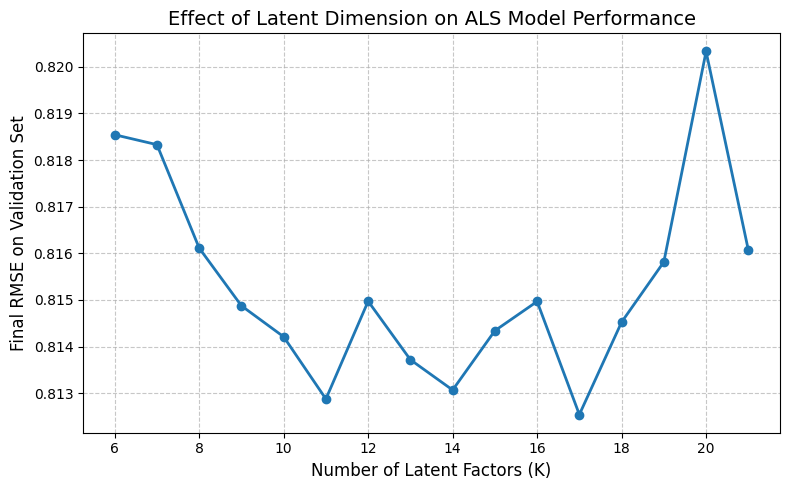

Best k:    11
Best RMSE: 0.813


In [25]:
import matplotlib.pyplot as plt

# Plot RMSE against latent dimension size
plt.figure(figsize=(8, 5))
plt.plot(Ks, Final_RMSEs, marker='o', linewidth=2, markersize=6)
plt.title(
    "Effect of Latent Dimension on ALS Model Performance", fontsize=14
)
plt.xlabel("Number of Latent Factors (K)", fontsize=12)
plt.ylabel("Final RMSE on Validation Set", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Best k:    {np.argmin(Final_RMSEs)}")
print(f"Best RMSE: {np.min(Final_RMSEs):.3f}")

### Final model training with tuned hyperparameters

This cell retrains the full ALS-based recommender system using the best hyperparameters identified from previous tuning experiments, including the optimal latent dimension $k$.

The model jointly learns:
- user and item biases,
- user and item latent embeddings,
- feature-based item representations.

Each iteration performs alternating updates over all parameter blocks, followed by evaluation of:
- training reconstruction error,
- test RMSE for generalisation performance,
- and a regularised negative log-likelihood objective that combines data fit with bias, embedding, and feature consistency penalties.

This final training run provides the definitive model used for downstream evaluation and analysis.

In [8]:
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")
from utils import (
    update_user_bias,
    update_user_embedding,
    update_item_bias,
    update_item_embedding,
    update_feature_embedding,
)

lam = 0.01898130680363748
gamma = 0.15890276403138492
tau = 0.27460338330040934
k = 15

user_bias = np.zeros((n_users))
item_bias = np.zeros((n_items))
user_embedding = np.random.normal(scale=0.1, size=(n_users, k))
item_embedding = np.random.normal(scale=0.1, size=(n_items, k))
feature_embedding = np.random.normal(scale=0.11, size=(n_features, k))
mu_train = train_data[:, 2].mean()

nll = 0
nll_history = []
train_rmse_history = []
test_rmse_history = []
iterations = 25

for iteration in range(iterations):
    # user bias update
    user_bias = Parallel(n_jobs=-1)(
        delayed(update_user_bias)(
            user,
            mu_train,
            data_by_user_train,
            lam,
            gamma,
            tau,
            item_bias,
            user_bias,
            item_embedding,
            user_embedding,
        )
        for user in range(n_users)
    )
    user_bias = np.array(user_bias)

    # user embedding update
    user_embedding = Parallel(n_jobs=-1)(
        delayed(update_user_embedding)(
            user,
            mu_train,
            data_by_user_train,
            lam,
            gamma,
            tau,
            item_bias,
            user_bias,
            item_embedding,
            user_embedding,
        )
        for user in range(n_users)
    )
    user_embedding = np.vstack(user_embedding)

    # item bias update
    item_bias = Parallel(n_jobs=-1)(
        delayed(update_item_bias)(
            item,
            mu_train,
            data_by_movie_train,
            lam,
            gamma,
            tau,
            item_bias,
            user_bias,
            item_embedding,
            user_embedding,
        )
        for item in range(n_items)
    )
    item_bias = np.array(item_bias)

    # item embedding update
    item_embedding = Parallel(n_jobs=-1)(
        delayed(update_item_embedding)(
            item,
            mu_train,
            data_by_movie_train,
            lam,
            gamma,
            tau,
            item_bias,
            user_bias,
            item_embedding,
            user_embedding,
            item_features,
            feature_embedding,
        )
        for item in range(n_items)
    )
    item_embedding = np.vstack(item_embedding)

    # feature embedding update
    feature_embedding = update_feature_embedding(
        item_features, item_embedding, tau, lam=lam
    )

    # compute train RMSE
    uv_train = np.sum(
        user_embedding[train_coo.row] * item_embedding[train_coo.col], axis=1
    )
    pred_train = user_bias[train_coo.row] + item_bias[train_coo.col] + uv_train + mu_train
    diff_train = train_coo.data - pred_train
    squared_error = np.sum(diff_train**2)

    reg_user_bias = np.sum(user_bias**2)
    reg_item_bias = np.sum(item_bias**2)
    reg_user_emb = np.sum(user_embedding**2)

    reg_item_feature = 0.0
    for n in range(n_items):
        feats = item_features[n]
        F_n = np.sum(feats)
        s_n = np.zeros(k) if F_n == 0 else (feats @ feature_embedding) / np.sqrt(F_n)
        reg_item_feature += np.sum((item_embedding[n] - s_n) ** 2)

    reg_feature_emb = np.sum(feature_embedding**2)

    nll = (
        (lam / 2) * squared_error
        + (gamma / 2) * (reg_user_bias + reg_item_bias)
        + (tau / 2) * (reg_user_emb + reg_item_feature + reg_feature_emb)
    )
    nll_history.append(nll)

    train_rmse = np.sqrt(squared_error / len(train_coo.data))
    train_rmse_history.append(train_rmse)

    # compute test RMSE
    uv_test = np.sum(user_embedding[test_coo.row] * item_embedding[test_coo.col], axis=1)
    pred_test = user_bias[test_coo.row] + item_bias[test_coo.col] + uv_test + mu_train
    diff_test = test_coo.data - pred_test
    test_rmse = np.sqrt(np.sum(diff_test**2) / len(test_coo.data))
    test_rmse_history.append(test_rmse)

    print(
        f"Iteration {iteration + 1}, NLL = {nll:.4f}, "
        f"Train RMSE = {train_rmse:.4f}, Test RMSE = {test_rmse:.4f}"
    )

Iteration 1, NLL = 174166.7976, Train RMSE = 0.8310, Test RMSE = 0.8704
Iteration 2, NLL = 145774.2668, Train RMSE = 0.7429, Test RMSE = 0.8196
Iteration 3, NLL = 138141.9926, Train RMSE = 0.7187, Test RMSE = 0.7986
Iteration 4, NLL = 135049.9375, Train RMSE = 0.7089, Test RMSE = 0.7896
Iteration 5, NLL = 133345.8754, Train RMSE = 0.7036, Test RMSE = 0.7846
Iteration 6, NLL = 132273.2905, Train RMSE = 0.7002, Test RMSE = 0.7814
Iteration 7, NLL = 131564.9704, Train RMSE = 0.6981, Test RMSE = 0.7794
Iteration 8, NLL = 131078.1318, Train RMSE = 0.6967, Test RMSE = 0.7780
Iteration 9, NLL = 130728.2362, Train RMSE = 0.6956, Test RMSE = 0.7771
Iteration 10, NLL = 130465.8073, Train RMSE = 0.6949, Test RMSE = 0.7764
Iteration 11, NLL = 130261.9702, Train RMSE = 0.6944, Test RMSE = 0.7759
Iteration 12, NLL = 130099.4945, Train RMSE = 0.6939, Test RMSE = 0.7754
Iteration 13, NLL = 129967.6185, Train RMSE = 0.6936, Test RMSE = 0.7751
Iteration 14, NLL = 129859.2061, Train RMSE = 0.6933, Test R

### Save trained model and training history

This cell stores the final trained parameters and optimisation history to disk for later reuse and analysis.

The saved file includes:
- learned user and item biases,
- latent user, item, and feature embeddings,
- training curves for negative log-likelihood, train RMSE, and test RMSE,
- and the item ID mapping used during preprocessing.

This ensures that the trained model can be reloaded without retraining, enabling reproducibility and further evaluation or deployment.

In [ ]:
np.savez("../model/all_data.npz",
         user_bias=user_bias,
         item_bias=item_bias,
         user_embedding=user_embedding,
         item_embedding=item_embedding,
         feature_embedding=feature_embedding,
         nll_history=nll_history,
         train_rmse_history=train_rmse_history,
         test_rmse_history=test_rmse_history,
         item_id_map=item_id_map)